## Data Exploration & Loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import movecolumn as mc

In [2]:
# %load load_data.py
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files('blastchar/telco-customer-churn' , unzip = True)


Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


In [3]:
df = pd.read_csv("/Users/priyankavasavada/churn-ai-project/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [6]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


- It can be seen from the data that categorical values have 2, 3 or 4 unique values.
- For binary, we can give them value 0 and 1.
- And for those that have more than 3 we will perform one-hot encoding.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Binary Encoding

In [9]:
# Binary categorical columns (2 unique values)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'] 

#Mapping binary categorical columns to 0 and 1
df[binary_cols] = df[binary_cols].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})


/var/folders/1x/8n9sp1d54h1fylprb9y2rhgh0000gn/T/ipykernel_12209/665979551.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


## One-Hot Encoding 

In [10]:
#Categorical columns that have more than 2 unique values to encode
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

#One-hot encoding for multi-category columns
df = pd.get_dummies(df,columns=multi_cat_cols,drop_first=True)

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## Data Cleaning

In [12]:
#TotalCharges has the type object so lets inspect it further
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
df.isnull().sum()

customerID                                0
gender                                    0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                 

In [14]:
#Filling the NaN values with median
df['TotalCharges'].fillna(value = df['TotalCharges'].median(),inplace = True)

/var/folders/1x/8n9sp1d54h1fylprb9y2rhgh0000gn/T/ipykernel_12209/800459529.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(value = df['TotalCharges'].median(),inplace = True)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   PaperlessBilling                       7043 non-null   int64  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7043 non-null   float64
 10  Churn                                  7043 non-null   int64  
 11  Mult

In [17]:
mc.MoveToLast(df, 'Churn')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,0
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,1
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,0
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,1


In [18]:
df = df.drop('customerID', axis=1)

In [19]:
#Checking any duplicated rows
df.duplicated()

0       False
1       False
2       False
3       False
4       False
5       False
6       False
7       False
8       False
9       False
10      False
11      False
12      False
13      False
14      False
15      False
16      False
17      False
18      False
19      False
20      False
21      False
22      False
23      False
24      False
25      False
26      False
27      False
28      False
29      False
30      False
31      False
32      False
33      False
34      False
35      False
36      False
37      False
38      False
39      False
40      False
41      False
42      False
43      False
44      False
45      False
46      False
47      False
48      False
49      False
50      False
51      False
52      False
53      False
54      False
55      False
56      False
57      False
58      False
59      False
60      False
61      False
62      False
63      False
64      False
65      False
66      False
67      False
68      False
69      False
70      False
71    

In [22]:
#Changing boolean values to 0 and 1 for better analysis
boolean_cols = df.select_dtypes(include='bool').columns
df[boolean_cols] = df[boolean_cols].astype(int)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,0,1,0,1,0,1,29.85,29.85,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1,0,0,0,45,0,0,42.30,1840.75,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   MultipleLines_No phone service         7043 non-null   int64  
 10  MultipleLines_Yes                      7043 non-null   int64  
 11  Inte

In [24]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


In [15]:
df['FeedbackLength'] = df['CustomerFeedback'].str.len()
df['FeedbackLength'].describe()

count    7043.000000
mean      460.571205
std        68.197917
min       277.000000
25%       414.000000
50%       454.000000
75%       499.000000
max       840.000000
Name: FeedbackLength, dtype: float64

In [16]:
df['Churn'].value_counts(normalize = True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

***Sentiment Analysis***

In [17]:
from textblob import TextBlob

In [18]:
#Create a function to get sentiment polarity
def get_polarity(text):
    if pd.isna(text):
        return 0
    return TextBlob(text).sentiment.polarity


In [19]:
#Create a function to get sentiment subjectivity
def get_subjectivity(text):
    if pd.isna(text):
        return 0
    return TextBlob(text).sentiment.subjectivity

In [20]:
#Apply it to the CustomerFeedback column
df['Sentiment_Polarity']=df['CustomerFeedback'].apply(get_polarity)
df['Sentiment_Subjectivity']=df['CustomerFeedback'].apply(get_subjectivity)

In [21]:
#Polarity: Ranges from -1.0 (Extremely Angry/Negative) to 1.0 (Extremely Happy/Positive). A score of 0 is neutral. 
#Subjectivity: Ranges from 0 (Very Objective/Factual) to 1 (Very Subjective/Opinionated).
#Check the first few rows 
df[['CustomerFeedback','Sentiment_Polarity','Sentiment_Subjectivity']].head(10)

,CustomerFeedback,Sentiment_Polarity,Sentiment_Subjectivity
0,I have been using the DSL internet service fro...,0.129545,0.565909
1,I have been a customer with this company for o...,0.170833,0.441667
2,I recently signed up for DSL internet service ...,-0.228571,0.640476
3,I have been a loyal customer with this company...,0.215801,0.500541
4,I recently switched to this fiber optic intern...,0.030000,0.503333
5,"""I recently decided to churn from this interne...",0.083766,0.543506
6,I have been a customer with this company for 2...,0.212000,0.548000
7,I have been a customer with this company for 1...,0.094318,0.611364
8,I recently decided to cancel my service after ...,0.175000,0.502500
9,I have been a customer with this DSL provider ...,0.075000,0.625000


In [22]:
# Display of the top positive and negative feedback
top_negative = df.nsmallest(5, 'Sentiment_Polarity')[['CustomerFeedback', 'Sentiment_Polarity', 'Churn']]
top_positive = df.nlargest(5, 'Sentiment_Polarity')[['CustomerFeedback', 'Sentiment_Polarity', 'Churn']]

print("🔴 MOST NEGATIVE FEEDBACK")
display(top_negative.style.background_gradient(cmap='Reds_r', subset=['Sentiment_Polarity']))

print("\n\n🟢 MOST POSITIVE FEEDBACK")
display(top_positive.style.background_gradient(cmap='Greens', subset=['Sentiment_Polarity']))

🔴 MOST NEGATIVE FEEDBACK


,CustomerFeedback,Sentiment_Polarity,Churn
1312,"I recently signed up for DSL internet service with this provider on a month-to-month contract. However, after just one month, I decided to cancel due to subpar connection speeds and unreliable service. Despite the affordable monthly charges of $51.25, I found that the service did not meet my expectations. Additionally, having to pay by mailing a check was inconvenient and outdated. Overall, I was disappointed with my experience and would not recommend this provider to others.",-0.312500,Yes
910,"I have been a customer with this DSL internet provider for 30 months now, but unfortunately, I have decided to churn. Despite being on a one-year contract with monthly charges of $85.35, I have found that the service does not meet my needs and expectations. The internet connection is often slow and unreliable, causing frustration and inconvenience. Additionally, the automatic bank transfer payment method has been convenient, but I do not feel that I am getting value for the money I am paying. Overall, I am disappointed with the service and have decided to switch to a different provider.",-0.310000,Yes
6891,"I recently signed up for internet service with this provider, but unfortunately had to cancel after only 1 month. The monthly charges were affordable at $19.1, but I was disappointed to find out that internet service was not available in my area. I had to cancel my contract and switch to another provider. I also found the payment method of mailing a check to be inconvenient. Overall, I was not satisfied with my experience and would not recommend this provider to others.",-0.287500,Yes
4434,"I recently signed up for DSL internet service with this provider on a month-to-month contract. Unfortunately, after just one month, I decided to cancel due to slow and unreliable internet speeds. I found the monthly charges of $45.1 to be reasonable, but the service itself did not meet my expectations. Additionally, having to mail in a check for payment was inconvenient and outdated. Overall, I was disappointed with my experience and would not recommend this provider to others.",-0.275000,Yes
1116,"I recently switched to this company for their fiber optic internet service, but unfortunately I had to cancel after only one month. The monthly charges were reasonable at $70.4, but I had issues with the reliability of the service. Additionally, I found the payment method of electronic check to be inconvenient. I was disappointed to have to churn so soon after signing up.",-0.275000,Yes




🟢 MOST POSITIVE FEEDBACK


,CustomerFeedback,Sentiment_Polarity,Churn
970,I have been a customer with this DSL internet service provider for 7 months now and I am very satisfied with the service. The monthly charges of $24.35 are affordable and the automatic credit card payment method makes it convenient for me to pay my bills on time. The internet service has been reliable with no issues of churn. I am happy with my decision to sign a one year contract with this provider.,0.725000,No
2067,I have been a customer with this internet service provider for 7 months now and have been satisfied with their DSL internet service. The monthly charges of $35.3 are affordable and the payment method of mailing a check works well for me. I am happy to say that I have no plans to churn and will continue to be a customer for the remainder of my one-year contract.,0.650000,No
6121,"I have been a customer with this DSL internet service provider for 40 months now and I am very satisfied with the service. The monthly charges of $65.1 are reasonable for the reliable internet connection I receive. Despite being on a month-to-month contract and paying by mailed check, I have experienced no issues with billing or service interruptions. I have no plans to switch providers as I am happy with the service I am receiving.",0.612500,No
1858,"I have been a loyal customer with this company for over five years now and I have been very satisfied with the service provided. The automatic bank transfer payment method makes it convenient for me to pay my monthly charges of $19.45 on time. Although I do not have internet service with this company, I appreciate the affordable monthly rate and the reliable service they have provided me. I have had no issues with churn and I am happy to continue my contract with them.",0.594444,No
4321,"I have been a customer with this company for 6 years now and I have been very satisfied with their service. The automatic payment method through my credit card has made it convenient for me to pay my monthly charges of $24.75. Even though I do not have internet service with them, I have had no issues with their customer service or billing. I am happy to say that I have no plans to churn and will continue to be a loyal customer.",0.594444,No


**Churn stats visualization**

In [23]:
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})
features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'FeedbackLength', 'Sentiment_Polarity']
correlations = df[features + ['Churn_numeric']].corr()['Churn_numeric'].drop('Churn_numeric').sort_values()

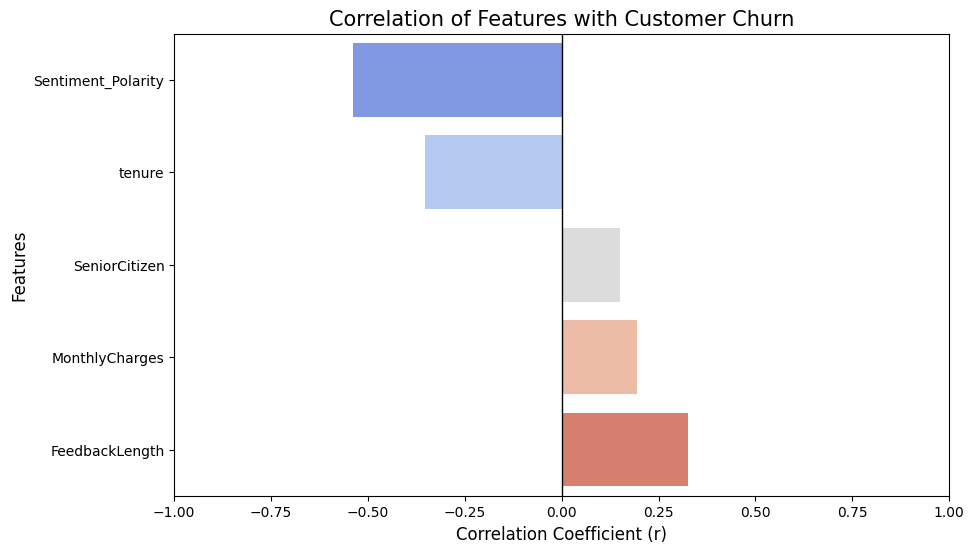

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

plt.title('Correlation of Features with Customer Churn', fontsize=15)
plt.xlabel('Correlation Coefficient (r)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xlim(-1, 1)
plt.axvline(0, color='black', lw=1) # Add a vertical line at 0
plt.show()

From the figure its observed:
1. As feedback length & Monthly charges increase, the customer is likely to churn since it becomes expensive and the feedback is usually emotionally charged and lengthy.
2. As sentiment polarity becomes more negative i.e. customers are angrier/unsatisfied, they are likely to churn.
3. Customers tend to stay when their stay has been longer with the company and they are less likely to churn.

**Binary Encoding**

In [25]:
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'
]
#Map binary columns to 0 and 1
df[binary_cols] = df[binary_cols].apply(lambda x: x.map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0 }))   

In [26]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback,FeedbackLength,Sentiment_Polarity,Sentiment_Subjectivity,Churn_numeric
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...,401,0.129545,0.565909,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...,399,0.170833,0.441667,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...,482,-0.228571,0.640476,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,Write a realistic customer feedback based on t...,I have been a loyal customer with this company...,406,0.215801,0.500541,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,Write a realistic customer feedback based on t...,I recently switched to this fiber optic intern...,418,0.030000,0.503333,1


In [ ]:
df.drop(columns = ['customerID', 'CustomerFeedback','FeedbackLength', ''], inplace = True)

**One-Hot Encoding**

In [34]:
#Categorical columns with more than 2 categories
categorical_cols = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']

NameError: name 'categorical_cols' is not defined